<a href="https://colab.research.google.com/github/KaisuH/Emotion-AI/blob/main/Emotion_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion AI

## Nutshell
As of now this project is under development.

This program classifies emotions from images of human faces. The dataset consists of over 20000 facial images that have been labeled with facial expression/emotion and approximately 2000 images with their keypoint annotations.

The program will train two models which will detect
1.   facial keypoints
2.   detect emotions.

Then these models are combined into one model that will provide a holistic prediction of the emotion as the output.

In [7]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
%cd '/content/drive/MyDrive/Colab Notebooks/Emotion-AI/'


/content/drive/MyDrive/Colab Notebooks/Emotion-AI


## Part 1. Key facial points detection

In this section I create a DL model with convolutional neural network and residual blocks to predict facial keypoints.
The data set is from https://www.kaggle.com/c/facial-keypoints-detection/overview.
The dataset consists of input images with 15 facial key points each.
The training.csv file has 7049 face images with corresponding keypoint locations. The test.csv file has face images only, and will be used to test the model.

### Importing libraries

In [21]:
# Import the necessary packages
import pandas as pd
import numpy as np
import os
import PIL
import seaborn as sns
import pickle
from PIL import *
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.python.keras import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
from keras import optimizers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow
import copy

### Load data

Here I load the dataset for training the model. The data consists of 31 columns: 2 columns for each of the 15 keypoints (x- and y-coordinates) and one image.

In [10]:
# load facial key points data
key_points_df = pd.read_csv('Data/data.csv')

In [11]:
key_points_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [12]:
# Are there null values?

key_points_df.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


The image data is an object that contains numbers as a string in the shape of (2140,). That has to be transformed into the real shape of the images (96, 96). Thus we create a 1-D array of the string and reshape it to 2D array.

In [13]:
key_points_df['Image'].shape
key_points_df['Image'][0]
type(key_points_df['Image'][0])

str

In [14]:
key_points_df['Image'] = key_points_df['Image']. apply(lambda img: np.fromstring(img, dtype = int, sep = ' ').reshape(96,96))


In [15]:
key_points_df['Image'][0].shape

(96, 96)

In [16]:
key_points_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


We perform a sanitz check for hte data by visualising 64 randomly chosen images along wiht their key facial points.

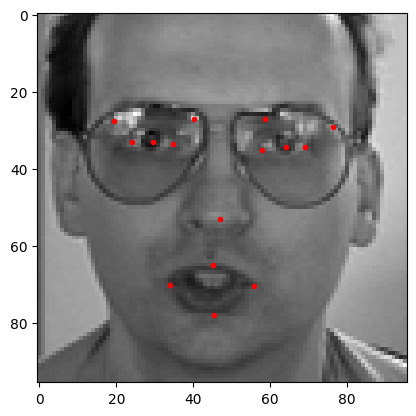

In [18]:
# A sample of the image data
i=6
col_num=len(key_points_df.columns)
plt.imshow(key_points_df['Image'][i],cmap='grey')
#generate a sequence of numbers starting from 1, going up to (but not including) 31, increasing by two at each step
for j in range(1,col_num,2):
  #Use .iloc for positional indexing
  plt.plot(key_points_df.iloc[i,j-1],key_points_df.iloc[i,j],marker='.', color='r')

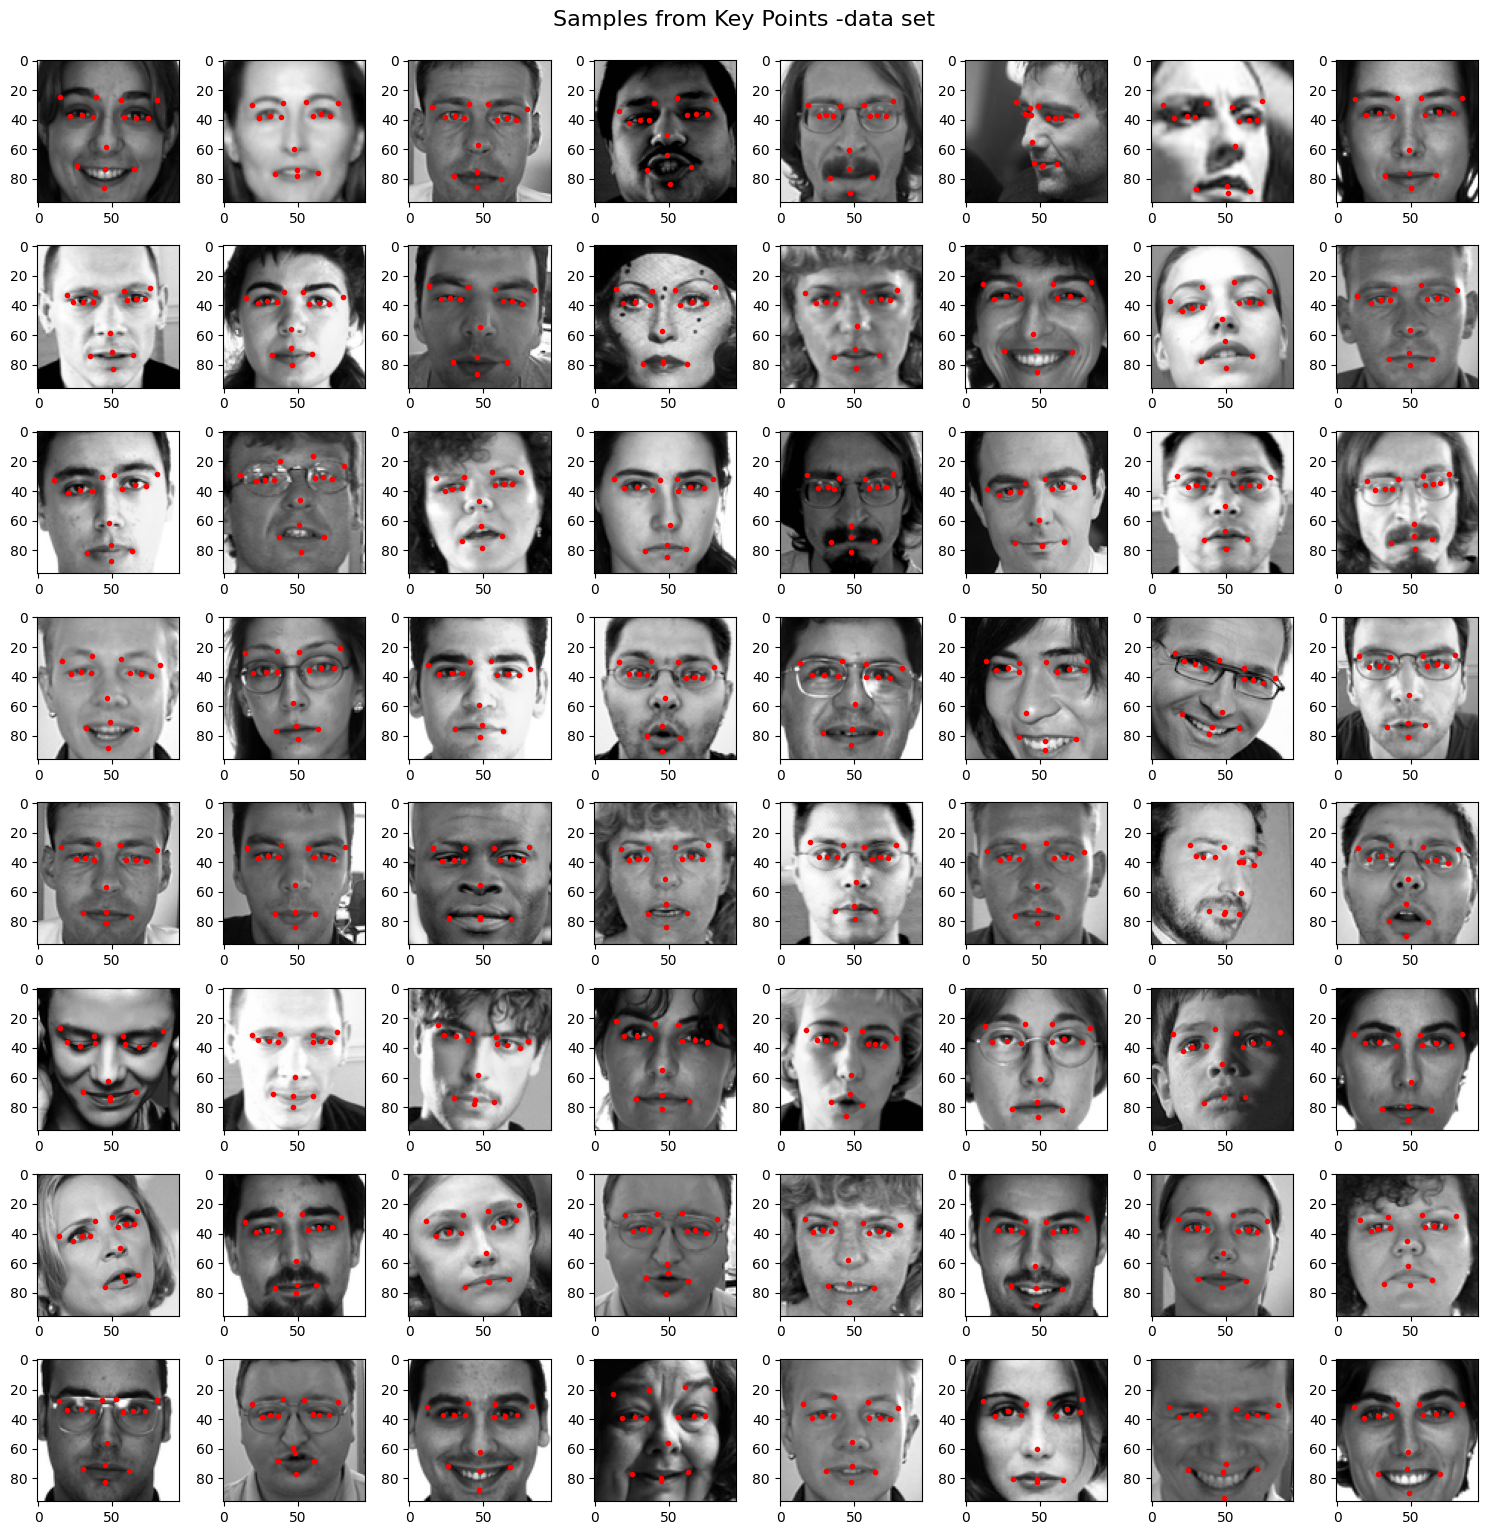

In [19]:
# Looking at a few more images

# Create a 4x4 grid of subplots
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(15, 15))  # Adjust figsize as needed
# Flatten the axes array for easy iteration
axes = axes.flatten()
for i in range(64):
  img_number=np.random.randint(0, 2139)
  ax = axes[i]
  ax.imshow(key_points_df['Image'][img_number],cmap='grey')
  #generate a sequence of numbers starting from 1, going up to (but not including) 31, increasing by two at each step
  for j in range(1,col_num,2):
    #Use .iloc for positional indexing
    ax.plot(key_points_df.iloc[img_number,j-1],key_points_df.iloc[img_number,j],marker='.', color='r')

# If there are any unused subplots, hide them
for j in range(64, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Optional: Add a main title for the entire figure
fig.suptitle('Samples from Key Points -data set', fontsize=16, y=1.02)  # y parameter adjusts the title position

# Display the plots
plt.show()


### Image augmentation

Here we create an additional data set where the images are changed slightly to improve the generalisation of the final AI model. We want more data and more variability in e.g. orientation, lighting conditions, or size of the image. This will reduce the likelihood of overfitting and ensuring that the model learns the meaningful "concepts" of emotion recognition. We create this extra data set by creating a copy of the original data set and tweaking it.


I will create 3 types of augmented images:
  1. horisontal flipping
  2. randomly increasing brightness
  3. vertical flipping

In [153]:
# Creating a new copy of the original data set
key_points_df_copy = copy.copy(key_points_df)

# Retrieve the columns in the dataframe except the image
columns = key_points_df_copy.columns[:-1]
columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y'],
      dtype='object')

In [154]:
# 1. Horizontal flip of the image along y axis
key_points_df_copy['Image'] = key_points_df_copy['Image'].apply(
    lambda img: np.flip(img, axis = 1))

# The y coordinates will stay the same.
# The x coordinates can be derived by extracting x-coordinate form
# the width of the image.

for i in range(len(columns)):
  if i % 2 == 0:
    key_points_df_copy[columns[i]] = key_points_df_copy[columns[i]].apply(lambda x: 96.- float(x))

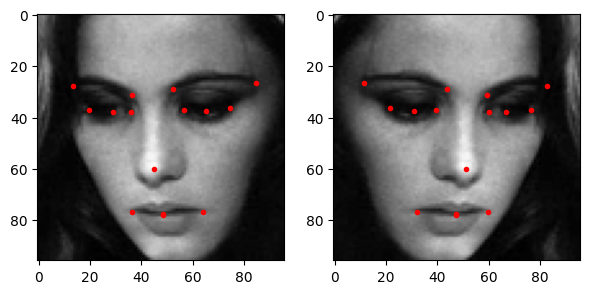

In [155]:
# Print the original and flipped image side by side
img = 2025

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 7))
axes[0].imshow(key_points_df['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[0].plot(key_points_df.iloc[img,j-1],key_points_df.iloc[img,j],marker='.', color='r')

axes[1].imshow(key_points_df_copy['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[1].plot(key_points_df_copy.iloc[img,j-1],key_points_df_copy.iloc[img,j],marker='.', color='r')
fig.show()

In [156]:
# Combine the augmented images to the original dataframe
augmented_df = np.concatenate((key_points_df, key_points_df_copy))
augmented_df.shape

(4280, 31)

In [157]:
# 2. Randomly increasing the brightness of images
# multiply pixel values by a random value between 1.5 and 2 to increase brightness
# values allowed are 0-255

key_points_df_copy = copy.copy(key_points_df)
key_points_df_copy['Image'] = key_points_df_copy['Image'].apply(
    lambda img: np.clip(img * np.random.uniform(1.5, 2), 0.0, 255))

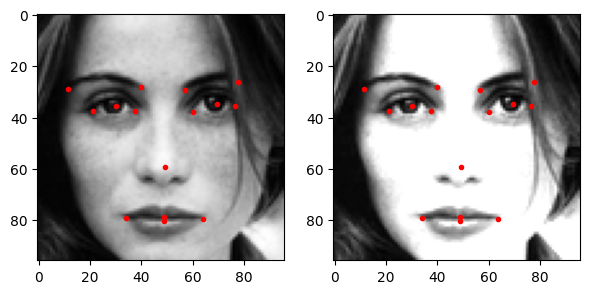

In [158]:
# Print the original and brightened image side by side
img = 2028

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 7))
axes[0].imshow(key_points_df['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[0].plot(key_points_df.iloc[img,j-1],key_points_df.iloc[img,j],marker='.', color='r')

axes[1].imshow(key_points_df_copy['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[1].plot(key_points_df_copy.iloc[img,j-1],key_points_df_copy.iloc[img,j],marker='.', color='r')
fig.show()

In [159]:
# Combine the augmented images to the original dataframe
augmented_df = np.concatenate((augmented_df, key_points_df_copy))
augmented_df.shape

(6420, 31)

In [160]:
# 3. Vertical fipping of images
key_points_df_copy = copy.copy(key_points_df)

key_points_df_copy['Image'] = key_points_df_copy['Image'].apply(
    lambda img: np.flip(img, axis = 0))

# The x coordinates will stay the same.
# The y coordinates can be derived by extracting x-coordinate form
# the width of the image.

for i in range(len(columns)):
  if i % 2 != 0:
    key_points_df_copy[columns[i]] = key_points_df_copy[columns[i]].apply(lambda y: 96.- float(y))

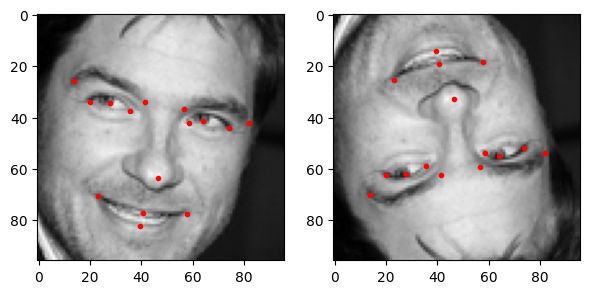

In [161]:
# Print the original and flipped image side by side
img = 2003

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 7))
axes[0].imshow(key_points_df['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[0].plot(key_points_df.iloc[img,j-1],key_points_df.iloc[img,j],marker='.', color='r')

axes[1].imshow(key_points_df_copy['Image'][img],cmap='grey')
for j in range(1, 31, 2):
    axes[1].plot(key_points_df_copy.iloc[img,j-1],key_points_df_copy.iloc[img,j],marker='.', color='r')
fig.show()

In [162]:
# Combine the augmented images to the original dataframe
augmented_df = np.concatenate((augmented_df, key_points_df_copy))
augmented_df.shape

(8560, 31)

### Data normalisation and scaling

I normalise the image pixel values to range 0 - 1. This generates better results in neural networks.


In [165]:
# Obtain the values of images (in the 31 st column)
img = augmented_df[:, 30]

# Normalize the images
img = img/255

# Initialise an empty array to feed to the model
img_array = np.empty((len(img), 96, 96, 1))

# Add image values to the img_array
for i in range(len(img)):
  img_array[i] = np.expand_dims(img[i], axis=2)

img_array.shape

(8560, 96, 96, 1)

In [167]:
# Obtain the x and y coordinates to be used as target
img_target = augmented_df[:,:30]
img_target = np.asarray(img_target).astype(np.float32)
img_target.shape

(8560, 30)

The dat ais generally devided in 80% training and 20% testing data. In general it is also recommended to further divide the training data to training data set (e.g. 60%) and validation data set (e.g. 20%).

In [168]:
# Split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(img_array, img_target, test_size=0.2, random_state=42)

In [169]:
X_train.shape

(6848, 96, 96, 1)

In [171]:
X_test.shape

(1712, 96, 96, 1)

### Neuron mathematical model - short recap

Artificial neurons are built in a similar way as human neurons. The artificial neurons take in signals through input channels (dendrites in human neurons) and processes information through transfer functions (cell bodies) and generates an output (which would travel through the axon of a neuronal cell).

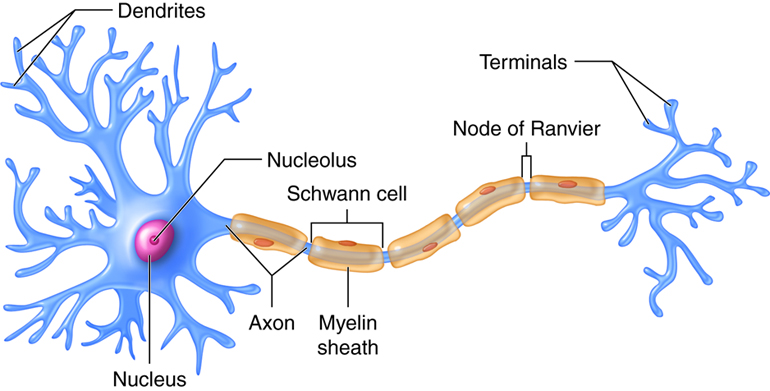

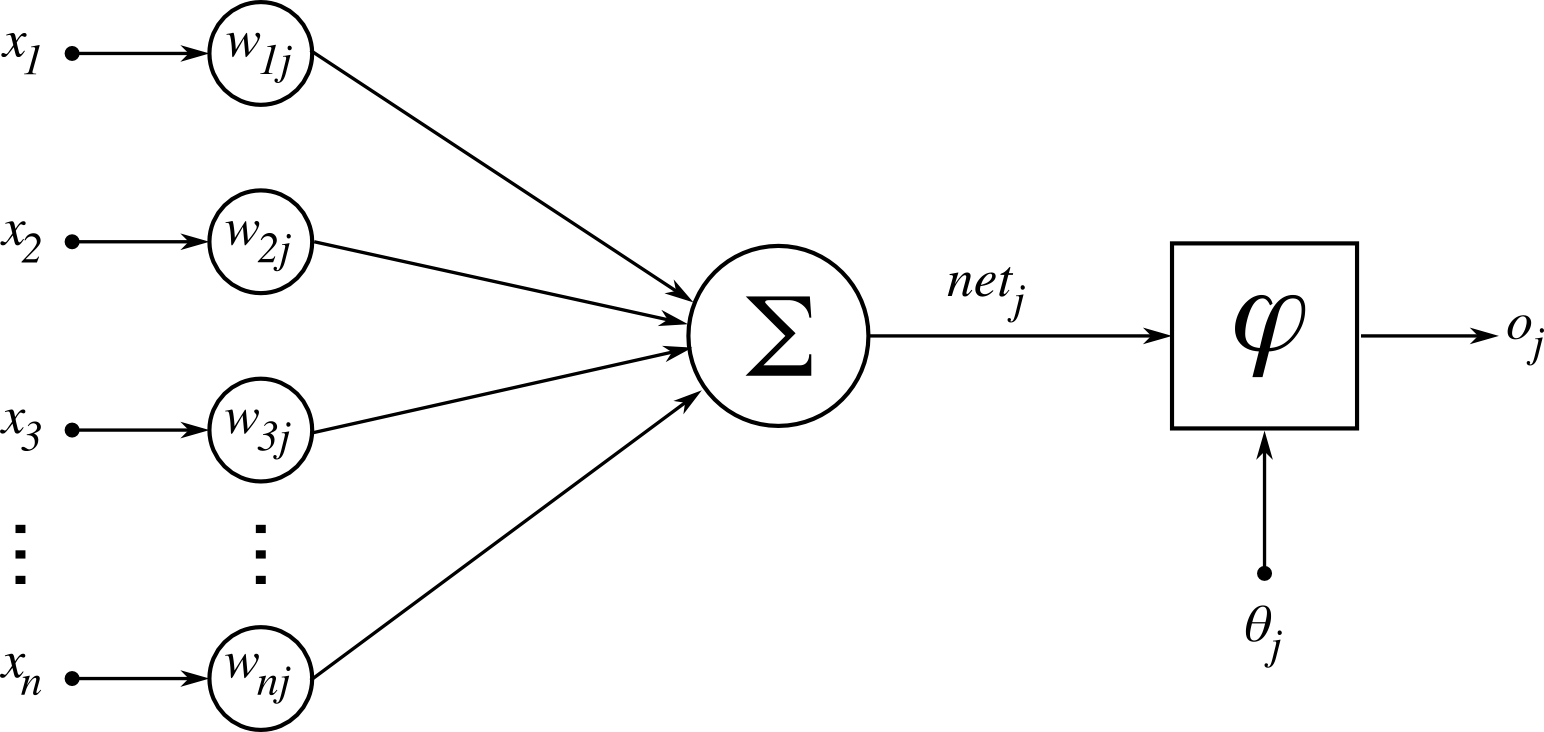

In [199]:
from IPython.display import Image, display
display(Image(filename='/content/drive/MyDrive/Colab Notebooks/Emotion-AI/neuron.jpeg', width=600))
display(Image(filename='/content/drive/MyDrive/Colab Notebooks/Emotion-AI/ArtificialNeuronModel.png', width=600))


Top image from Introduction to Psychology (A critical approach) Copyright © 2021 by Rose M. Spielman; Kathryn Dumper; William Jenkins; Arlene Lacombe; Marilyn Lovett; and Marion Perlmutter licensed under a Creative Commons Attribution 4.0 International License.
Bottom image from Chrislb, CC BY-SA 3.0 <http://creativecommons.org/licenses/by-sa/3.0/>, via Wikimedia Commons

For example lets consider an artificial neuron (AN) that takes three inputs: $x_1$, $x_2$, and $x_3$. We can then express the output of the artificial neuron mathematically as
$y = \phi(X_1W_1 + X_2W_2 + X_3W_3 + b)$. Here $y$ is the output and the $W$s are the weights assigned to each input signal. $b$ is a bias term added to the weighted sum of inputs. $\phi$ is the activation function.

Some common modern activation functions used in neural networks are for example ReLU, GELU and the logistic activation function. ReLU is short for Rectified linear unit function and is defined as
$\phi(x) = max(0,\alpha + x'b)$. ReLU is recommended for the hidden layers, since it outputs a linear response for positive values. This helps maintain larger gradients and makes training deep networks more feasible.

The Gaussian Error Linear Unit (GELU) is a smoother version of the ReLU and is defined as
$x\phi(x)$, where the $\phi(x)$ stands for Gaussian cumulative distribution function.

The logistic activation function is also called sigmoid function and is defined as
 $\phi(x) = \frac{1}{1+e^{-x}}$. It takes a number and sets it between 0 and 1 and thus is very helpful in output layers.


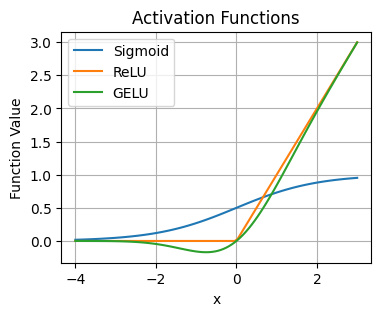

In [194]:
# Display the activation functions
def sigmoid(x):
  """Calculates the sigmoid function for a given input."""
  return 1 / (1 + np.exp(-x))

def relu(x):
  """Calculates the ReLU function for a given input."""
  return np.maximum(0, x)

def gelu(x):
  """Calculates the GELU function for a given input (with the approximation)."""
  return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

# Generate x values for the plot
x = np.linspace(-4, 3, 100)  # 100 points between -10 and 10

# Calculate the corresponding function values
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_gelu = gelu(x)

# Create the plot with a smaller figure size
plt.figure(figsize=(4, 3))  # Adjust figure size here (width, height)
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_gelu, label='GELU')
plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('Function Value')
plt.grid(True)
plt.legend()
plt.show()

The artificial neurons are connected to each other to form neural networks and a plethora of different network architectures exist. To harness the power of AI, it is necessary to know which architecture serves the intended purpose best. Below are three common architectures and their applications.

Convolutional Neura Networks (CNN) are designed to process data with a grid-like topology and are most commonly used in image analysis. They utilise convolutional layers to learn spatial hierarchies by applying filters (kernels) that slide (convolve) over the input. They usually involve pooling layers that reduce the spatial dimensions and fully connected layers that map the extracted features to outputs.





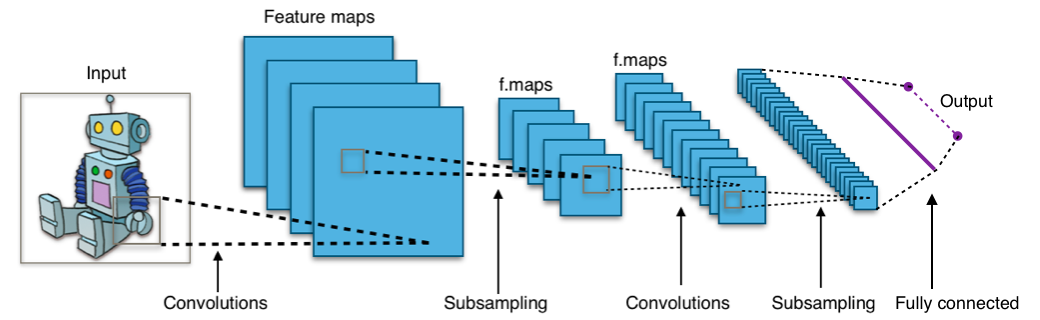

In [191]:
display(Image(filename='/content/drive/MyDrive/Colab Notebooks/Emotion-AI/Typical_cnn.png', width=600))

Image credit: Aphex34, CC BY-SA 4.0 <https://creativecommons.org/licenses/by-sa/4.0>, via Wikimedia Commons

Recurrent Neural Networks (RNNs) handle sequential data by maintaining a hidden state that captures information about previous elements in the sequence. Therefore they are great for contexts where the output depends on previous inputs, for example time series and natural language processing.

Generative Adversial Networks (GANs) consist of two neural networks - the Generator and the Discriminator. They sparr each other in a zero-sum game framework, where the genrator creates synthetic data that resembles real data and the discriminator evaluates whether it is rela or not. This dirves the generator to output increasingly realistic data. Obviously, this is the choice for many image generation and editing but also for anomaly detection in industiral and security contexts. GANs can model regular patterns and subsequently detect anomalies by comparing generated outputs with real inputs.

### Training

All neural networks need to be trained. This happens by adjusting the weights of the network, by iteratively minimising the cost function using for example the gradient descent optimization algorithm. It works by calculating the gradient of the cost function and then takes a step to the negative direction until it reaches the local or global minimum.

A typical choice for a cost function is the quadratic loss, which is formulated as $f_{loss}(w,b)= \frac{1}{N}\sum^n_{i=1}(\hat y-y)$.

Gradient descent algorithm:
  1. Calculate the derivative of the loss function $\frac{\delta f_{loss}}{\delta w}$
  2. Pick random valeus for weights and substitute.
  3. Calculate the step size, i.e. how much we will update our weights.

  step size = learning rate * gradient $=\alpha*\frac{\delta f_{loss}}{\delta w}$
  4. Update the parameters and repeat.

  new weight = old weight - step size
  $w_{new}=w_{old}-\alpha*\frac{\delta f_{loss}}{\delta w}$

Below is an example for searching the minimum of a u-shaped funciton with gradient descent. Usually the situation is mulidimensional but the simplification is solved in a similar way.

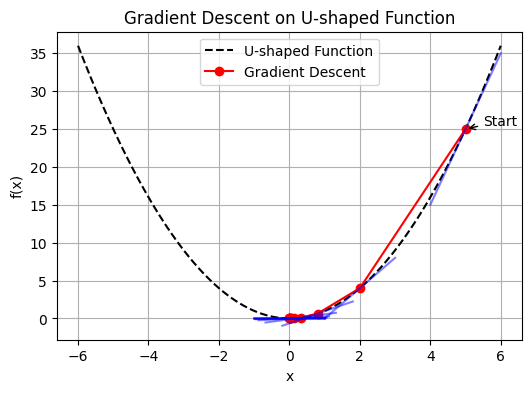

In [204]:

def u_shaped_function(x):
    return x**2

def gradient(x):
    return 2 * x

def visualize_gradient_descent(learning_rate, iterations):
    """
    Visualizes gradient descent on a U-shaped function.

    Args:
        learning_rate: The learning rate for gradient descent.
        iterations: The number of iterations to perform.
    """
    x_start = 5
    x_values = [x_start]
    y_values = [u_shaped_function(x_start)]
    tangents = []

    for i in range(iterations):
        x_current = x_values[-1]
        gradient_current = gradient(x_current)
        x_next = x_current - learning_rate * gradient_current
        x_values.append(x_next)
        y_values.append(u_shaped_function(x_next))

        tangent_x = np.linspace(x_current - 1, x_current + 1, 10)
        tangent_y = u_shaped_function(x_current) + gradient_current * (tangent_x - x_current)
        tangents.append((tangent_x, tangent_y))

    plt.figure(figsize=(6, 4))
    x_range = np.linspace(-6, 6, 100)
    plt.plot(x_range, u_shaped_function(x_range), 'k--', label='U-shaped Function')
    plt.plot(x_values, y_values, 'ro-', label='Gradient Descent')

    for tangent_x, tangent_y in tangents:
        plt.plot(tangent_x, tangent_y, 'b-', alpha=0.5)

    plt.annotate('Start', (x_start, u_shaped_function(x_start)),
                 xytext=(x_start + 0.5, u_shaped_function(x_start) + 0.5),
                 arrowprops=dict(arrowstyle='->'))

    plt.title('Gradient Descent on U-shaped Function')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()


visualize_gradient_descent(learning_rate=0.3, iterations=10)

Testing various learning rates helps undestand the importance of choosing the parameters of training.

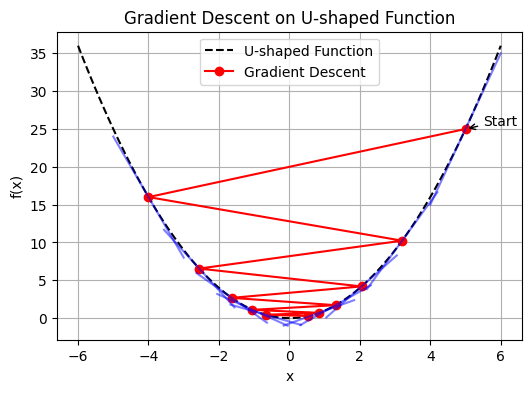

In [206]:
visualize_gradient_descent(learning_rate=0.9, iterations=10)

In [212]:
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>Gradient Descent Visualization</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
</head>
<body>
    <h1>Gradient Descent Visualization</h1>
    <div>
        Learning Rate: <input type="number" id="learningRate" value="0.3" step="0.1">
        Iterations: <input type="number" id="iterations" value="10" step="1">
        <button onclick="updateChart()">Update</button>
    </div>
    <canvas id="myChart"></canvas>

    <script>
        function uShapedFunction(x) {
    return x * x;
}

function gradient(x) {
    return 2 * x;
}

function gradientDescent(learningRate, iterations) {
    let xStart = 5;
    let xValues = [xStart];
    let yValues = [uShapedFunction(xStart)];

    for (let i = 0; i < iterations; i++) {
        let xCurrent = xValues[xValues.length - 1];
        let gradientCurrent = gradient(xCurrent);
        let xNext = xCurrent - learningRate * gradientCurrent;
        xValues.push(xNext);
        yValues.push(uShapedFunction(xNext));
    }

    return { xValues, yValues };
}

function updateChart() {
    let learningRate = parseFloat(document.getElementById("learningRate").value);
    let iterations = parseInt(document.getElementById("iterations").value);

    let { xValues, yValues } = gradientDescent(learningRate, iterations);

    let ctx = document.getElementById('myChart').getContext('2d');
    let myChart = new Chart(ctx, {
        type: 'line',
        data: {
            labels: xValues,
            datasets: [{
                label: 'Gradient Descent',
                data: yValues,
                borderColor: 'red',
                fill: false
            }]
        },
        options: {
            responsive: true,
            scales: {
                x: {
                    display: true,
                    title: {
                        display: true,
                        text: 'x'
                    }
                },
                y: {
                    display: true,
                    title: {
                        display: true,
                        text: 'f(x)'
                    }
                }
            }
        }
    });
}

// Initial chart rendering
updateChart();
    </script>
</body>
</html>
"""

# Git commands
Storage for git commands

In [220]:
# Run this after saving
# Git config
!git config user.name "KaisuH"
!git config user.email "51493218+KaisuH@users.noreply.github.com"

In [251]:
# Add changes
!git add .

In [252]:
# Commit changes and remember to change commit message
!git commit -m "Added html file for github pages"

On branch main
nothing to commit, working tree clean


In [234]:
mv .gitignore.txt .gitignore


mv: cannot stat '.gitignore.txt': No such file or directory


In [250]:
# Push changes
with open('/content/drive/MyDrive/tokens/token1.txt', 'r') as f:
    token = f.read().strip()

!git push https://$token@github.com/KaisuH/Emotion-AI.git

To https://github.com/KaisuH/Emotion-AI.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/KaisuH/Emotion-AI.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [237]:
!git reset --soft HEAD~1

In [240]:
!git rm -r -f --cached Data/


rm 'Data/Emotion+AI+Dataset.zip'
rm 'Data/augmented.csv'
rm 'Data/data.csv'
rm 'Data/detection.json'
rm 'Data/emotion.json'
rm 'Data/face_detection.json'
rm 'Data/facial_detection.ipynb'
rm 'Data/icml_face_data.csv'
rm 'Data/models.config'
rm 'Data/server.log'
rm 'Data/test.csv'
rm 'Data/training.csv'
rm 'Data/weights.h5'
rm 'Data/weights.hdf5'
rm 'Data/weights_emotion.hdf5'
rm 'Data/weights_emotions.hdf5'
rm 'Data/weights_keypoint.hdf5'


In [246]:
!jupyter nbconvert --to html "Emotion_AI.ipynb"


[NbConvertApp] Converting notebook Emotion_AI.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 3143965 bytes to Emotion_AI.html


In [ ]:
!git pull